# Step size scheduling

The following is a discussion on step sizes within the IAS15 integrator. It does not apply to fixed step sizes integrators like any of the built-in symplectic leapfrog schemes.

The "A" in IAS15 stands for "adaptive", meaning the integrator is allowed to choose and change its step size as it evolves the system. To set up this adaptation, we must first make two choices:

1. Do we want to take a step that lands exactly on every requested output time, or do we want to allow the integrator to take "natural" steps until it passes the latest requested output time, then to "interpolate" among the outputs to solve the positions and velocities at arbitrary intermediate times? Here we don't mean "interpolate" in the usual sense where we lose information while guessing a trajectory between known locations. As described in the [IAS15 paper](https://scixplorer.org/abs/2015MNRAS.446.1424R/abstract), the integrator evaluates positions and velocities by first running a predictor-corrector loop to solve for a 7th-order polynomial approximation of the acceleration within one time step, then integrates this polynomial using Gauss-Radau quadrature to get the positions and velocities at the end of the step. But, if we instead evaluate that same integral at a slightly earlier sub-step time, we can recreate the positions and velocities at that time with no* loss of information (TODO: figure out if we actually do lose information since we aren't using the Gauss-Radau nodes when we evaluate the integral at arbitrary H values.) This choice is the difference between `integrate` and `integrate_or_interpolate` in both the `REBOUND` and `jorbit` APIs (TODO: finish actually implementing this API in `jorbit`, replace all the bits about forced_landing)
   
2. Regardless if we're willing to overshoot and interpolate or not, how do we define a "natural" step size? There are two candidate algorithms for this. The ["PRS23" algorithm](https://scixplorer.org/abs/2024OJAp....7E...1P/abstract) from Pham+ 2023, which is the default in `jorbit` and has been the default in `REBOUND` since 2024, and the "global" step size controller from the original `IAS15` paper.

That leaves us with four possible combinations of step size scheduling:
| Step size scheduling | Output times |
|----------------------|--------------|
| PRS23                | Forced landing |
| PRS23                | Interpolation |
| Global               | Forced landing |
| Global               | Interpolation |

Here's what these four options look like using both codes:

In [17]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import pprint
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time

from jplephem.spk import SPK

import rebound
import assist
from rebound import Particle as rebound_Particle

from jorbit import Particle
from jorbit.accelerations import (
    create_default_ephemeris_acceleration_func,
    create_newtonian_ephemeris_acceleration_func,
    create_ephem_grav_harmonics_acceleration_func,
    nongrav_acceleration,
)
from jorbit.data.constants import (
    EARTH_J_HARMONICS,
    EARTH_RADIUS,
    SPEED_OF_LIGHT,
    SUN_J_HARMONICS,
    SUN_RADIUS,
)
from jorbit.ephemeris import Ephemeris, EphemerisProcessor
from jorbit.utils.horizons import horizons_bulk_vector_query
from jorbit.utils.states import CartesianState, SystemState, KeplerianState

# Build the time grid in TDB directly. `Time("2029-01-01")` would default to
# UTC and `.tdb.jd` would silently shift by ~69 s (TAI/TT/TDB offsets at this
# epoch), giving an IC ~140,000 km off from the bundle in
# docs/misc/rebound_apophis_dumps/run_simulations.py. We construct in TDB so
# the year-long step counts here match the cached `sim1`/`sim2` exactly.
times = Time(
    np.linspace(
        Time("2029-01-01", scale="tdb").tdb.jd,
        Time("2030-01-01", scale="tdb").tdb.jd,
        1000,
    ),
    format="jd",
    scale="tdb",
)
# change these to your local path- jorbit doesn't store these files, see ASSIST docs for more
ephem = assist.Ephem(
    "/Users/cassese/Downloads/linux_p1550p2650.440",
    "/Users/cassese/Downloads/sb441-n16.bsp",
)

# get the Sun's position and velocity from the usual jorbit interface-
# the Apophis SPK's are relative to the Sun, not the solar system barycenter
usual_eph = Ephemeris(ssos="default solar system")
eph_state = usual_eph.state(times)
sun_xs = eph_state["sun"]["x"].value
sun_vs = eph_state["sun"]["v"].value
earth_xs = eph_state["earth"]["x"].value
earth_vs = eph_state["earth"]["v"].value


def parse_apophis_file(filename):

    # open ephemeris
    spk = SPK.open(filename)
    starts = np.array([seg.start_jd for seg in spk.segments])
    ends = np.array([seg.end_jd for seg in spk.segments])
    order = starts.argsort()
    starts = jnp.array(starts[order])
    ends = jnp.array(ends[order])

    # create a list of EphemerisProcessor objects for each segment
    processors = []
    for ind in order:
        init, intlen, coeff = spk.segments[ind]._data
        processors.append(
            EphemerisProcessor(
                jnp.array([init]),
                jnp.array([intlen]),
                jnp.array([coeff]),
                jnp.array([0.0]),
            )
        )

    # figure out which processor to use for each time
    processor_inds = jnp.searchsorted(starts, times.tdb.jd) - 1

    # query those processors for the state of Apophis, then subtract off the sun's position
    helio_xs = np.zeros((len(processor_inds), 3))
    helio_vs = np.zeros((len(processor_inds), 3))
    for i, (ind, t) in enumerate(zip(processor_inds, times.tdb.jd)):
        _x, _v = processors[ind].state(t)
        helio_xs[i] = _x[0]
        helio_vs[i] = _v[0]
    final_xs = helio_xs + sun_xs
    final_vs = helio_vs + sun_vs

    return jnp.array(final_xs), jnp.array(final_vs)


jpl_220_xs, jpl_220_vs = parse_apophis_file("../../paper/data/sb-99942-220.bsp")

In [18]:
x0 = jpl_220_xs[0]
v0 = jpl_220_vs[0]


# Setup matches docs/misc/rebound_apophis_dumps/run_simulations.py:
#   * particle IC and time set with float() casts
#   * extras.forces = FULL_FORCES (FP-summation is non-associative across forces,
#     so the order matters; matching the bundle here lets year-long step counts
#     line up with the cached `sim1`/`sim2`)
#   * sim.dt, sim.ri_ias15.epsilon, sim.ri_ias15.min_dt, adaptive_mode set explicitly
#   * `extras.integrate_or_interpolate(t)` per output time for the interpolate
#     branches (the canonical ASSIST API for sampling a trajectory at requested
#     times under dense output) and `sim.integrate(t)` per output time for the
#     forced-landing branches.
NONGRAV = (4.999999873689e-13, -2.901085508711e-14, 0.0)
FULL_FORCES = [
    "SUN",
    "PLANETS",
    "ASTEROIDS",
    "GR_EIH",
    "SUN_HARMONICS",
    "EARTH_HARMONICS",
    "NON_GRAVITATIONAL",
]


def assist_sim(scheduler, interpolate):
    sim = rebound.Simulation()
    sim.add(
        rebound_Particle(
            x=float(x0[0]),
            y=float(x0[1]),
            z=float(x0[2]),
            vx=float(v0[0]),
            vy=float(v0[1]),
            vz=float(v0[2]),
        )
    )
    sim.t = float(times[0].tdb.jd) - ephem.jd_ref

    extras = assist.Extras(sim, ephem)
    extras.forces = FULL_FORCES
    extras.gr_eih_sources = 11
    extras.particle_params = np.array(NONGRAV, dtype=np.float64)

    sim.dt = 0.001
    sim.ri_ias15.epsilon = 1e-9
    sim.ri_ias15.min_dt = 0.001
    sim.ri_ias15.adaptive_mode = scheduler

    assist_xs = np.zeros((len(times), 3))
    assist_vs = np.zeros((len(times), 3))
    for i, t in enumerate(times):
        if interpolate:
            extras.integrate_or_interpolate(float(t.tdb.jd) - ephem.jd_ref)
        else:
            sim.integrate(float(t.tdb.jd) - ephem.jd_ref)
        assist_xs[i] = sim.particles[0].xyz
        assist_vs[i] = sim.particles[0].vxyz
    return assist_xs, assist_vs, sim.steps_done


assist_results = {}
for scheduler in ["prs23", "global"]:
    for interpolate in [False, True]:
        x, v, s = assist_sim(scheduler, interpolate)
        assist_results[(scheduler, interpolate)] = (x, v, s)

In [19]:
# construct each component of the acceleration function piece-by-piece

# first, just the usual gravitational acceleration function, GR for planets, newtonian for asteroids
eph = Ephemeris(ssos="default solar system")
acc_func_grav = create_default_ephemeris_acceleration_func(
    ephem_processor=eph.processor
)

# add the J harmonics for the Sun and Earth
acc_func_solar_harmonics = create_ephem_grav_harmonics_acceleration_func(
    eph.processor, ephem_index=0, state_index=0
)
acc_func_earth_harmonics = create_ephem_grav_harmonics_acceleration_func(
    eph.processor, ephem_index=3, state_index=1
)


# combine those 3, along with the non-gravitational forces
# (which didn't need to be created separately since it just relies on SystemState)
def _acc_func(state: SystemState) -> jnp.ndarray:
    return (
        acc_func_grav(state)
        + nongrav_acceleration(state)
        + acc_func_solar_harmonics(state)
        + acc_func_earth_harmonics(state)
    )


acc_func = jax.tree_util.Partial(_acc_func)

# set the J coefficients
js = jnp.zeros((2, 3))
js = js.at[0, 0].set(SUN_J_HARMONICS[0])
js = js.at[1].set(EARTH_J_HARMONICS)

acceleration_func_kwargs = {
    "c2": SPEED_OF_LIGHT**2,
    "a1": jnp.array([4.999999873689e-13]),  # the same non-grav coefficients
    "a2": jnp.array([-2.901085508711e-14]),
    "a3": jnp.array([0.0]),
    "js_req": jnp.array([SUN_RADIUS, EARTH_RADIUS]),
    "js_pole_ra": jnp.array(
        [286.13 * jnp.pi / 180, 359.99868 * jnp.pi / 180]
    ),  # the RA and Dec of the poles in April 2029
    "js_pole_dec": jnp.array([63.87 * jnp.pi / 180, 89.83523 * jnp.pi / 180]),
    # "js_pole_ra": jnp.array(
    #     [286.13 * jnp.pi / 180, 0.0]
    # ),  # the RA and Dec of the poles in April 2029
    # "js_pole_dec": jnp.array([63.87 * jnp.pi / 180, 90.0 * jnp.pi / 180]),
    "js": js,
}

c = CartesianState(
    x=jnp.array([jpl_220_xs[0]]),
    v=jnp.array([jpl_220_vs[0]]),
    time=times[0].tdb.jd,
    acceleration_func_kwargs=acceleration_func_kwargs,
)

p = Particle(state=c, gravity=acc_func)

jorb_results = {}
for scheduler in ["prs23", "global"]:
    for interpolate in [False, True]:
        if interpolate:
            xs, vs, steps = p.integrate_or_interpolate(
                times, step_scheduler=scheduler, return_steps=True
            )
        else:
            xs, vs, steps = p.integrate(
                times, step_scheduler=scheduler, return_steps=True
            )
        xs.block_until_ready()
        jorb_results[(scheduler, interpolate)] = (xs, vs, steps)

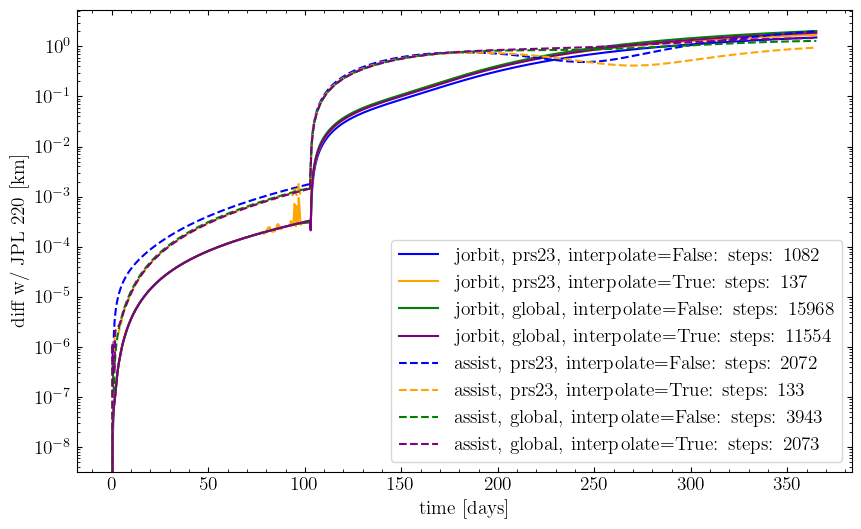

In [20]:
colors = ["blue", "orange", "green", "purple"]
fig, ax = plt.subplots(figsize=(10, 6))
for i, ((scheduler, interpolate), (xs, vs, steps)) in enumerate(jorb_results.items()):
    label = f"jorbit, {scheduler}, interpolate={interpolate}: steps: {steps}"
    ax.plot(
        times.mjd - times.mjd[0],
        jnp.linalg.norm(xs - jpl_220_xs, axis=1) * u.au.to(u.km),
        color=colors[i],
        label=label,
    )


for i, ((scheduler, interpolate), (xs, vs, steps)) in enumerate(assist_results.items()):
    label = f"assist, {scheduler}, interpolate={interpolate}: steps: {steps}"
    ax.plot(
        times.mjd - times.mjd[0],
        jnp.linalg.norm(xs - jpl_220_xs, axis=1) * u.au.to(u.km),
        label=label,
        color=colors[i],
        linestyle="dashed",
    )

ax.set(
    yscale="log",
    xlabel="time [days]",
    ylabel="diff w/ JPL 220 [km]",
)

ax.legend()

## Reading the residual plot

Two things in the plot above are worth dissecting.

**(1) The pre-flyby chatter at days ~92–98.** The `jorbit, prs23, interpolate=True` curve develops a sub-meter oscillation in the run-up to the close approach. None of the other seven curves do. The `jorbit, prs23, interpolate=False` curve at the same days is smooth, so this is *intra-step* behavior — something about the dense-output polynomial inside one of jorbit's natural steps. Section "Zoom in on the chattery step" tracks this down.

**(2) The factor of ~6 step-count gap between `jorbit, global, interpolate=True` and `assist, global, interpolate=True`.** ASSIST takes a few thousand steps to cross the year; jorbit takes ~15× more. Both controllers use the same formula and the same `min_dt = 0.001` floor. If both codes implemented the same algorithm and saw the same gravity, they would take the same number of steps. They don't. The remaining sections show *why*: the two codes' converged b coefficients differ post-flyby by a large factor, and that difference enters the gravity evaluation chain — not the predictor, and not the predictor-corrector arithmetic.

The post-flyby IC and several single-step diagnostics used below come from the cached REBOUND/ASSIST dumps in `docs/misc/rebound_apophis_dumps/outputs/`. See `docs/misc/rebound_apophis_dumps/README.md` for how those are regenerated.

## Zoom in on the chattery step

The chatter is intra-step — the forced-landing PRS23 curve is smooth across the same days, so the natural step boundary itself is fine. What's drifting is the *interior* of one specific natural step. We pull out that step's converged dense-output polynomial and compare it, point-by-point, against jorbit's own forced-landing run sampled at the same fine grid of sub-times. Forced-landing inside that window takes many small natural steps and its endpoints carry only the integrator's own per-step error budget, so it's a reasonable reference for what the trajectory "really" is.

The integrator state, force model, and IC are all the same as the year-long PRS23 run above (cell with the `acc_func` and `Particle` build). We just expose the per-step dense output via `ias15_evolve_with_dense_output` so we can introspect one step's `b` coefficients directly.

In [21]:
from jorbit.integrators.ias15 import (
    ias15_evolve_with_dense_output,
    initialize_ias15_integrator_state,
    next_proposed_dt_PRS23,
    _estimate_x_v_from_b,
    IAS15_MAX_DYNAMIC_STEPS,
)
from jorbit.data.constants import IAS15_H

# Re-run jorbit PRS23+interpolate over a window covering the chatter, exposing
# the per-step dense-output buffers so we can introspect one step's `b`.
# We integrate to days 70..120 (containing the chatter and a few free steps on
# either side) so the relevant step is mid-buffer.
window = Time(
    np.linspace(times[0].tdb.jd + 70.0, times[0].tdb.jd + 120.0, 200),
    format="jd",
    scale="tdb",
)

state0 = c.to_system()
a0_init = acc_func(state0)
intg_state0 = initialize_ias15_integrator_state(a0_init)

(
    _xs_win,
    _vs_win,
    _final_sys,
    _final_intg,
    _iter_num,
    b_buf,
    a0_buf,
    x0_buf,
    v0_buf,
    dts_buf,
    t_step_starts,
    _step_inds,
    _h_vals,
) = ias15_evolve_with_dense_output(
    state0,
    acc_func,
    jnp.array(window.tdb.jd),
    intg_state0,
    jax.tree_util.Partial(next_proposed_dt_PRS23),
)

# dts_buf is sized to IAS15_MAX_DYNAMIC_STEPS; unused tail entries are 0.
n_steps_recorded = int(jnp.sum(dts_buf > 0))
print(
    f"PRS23 dense-output buffer holds {n_steps_recorded} natural steps "
    f"(cap {IAS15_MAX_DYNAMIC_STEPS}); the chatter window is at the start of the year."
)

# Pick the offending step: largest dt in [day 90, day 100).
day_lo, day_hi = 90.0, 100.0
t_jd_lo = times[0].tdb.jd + day_lo
t_jd_hi = times[0].tdb.jd + day_hi
candidate = jnp.where(
    (t_step_starts >= t_jd_lo) & (t_step_starts < t_jd_hi) & (dts_buf > 0)
)[0]
step_idx = int(candidate[jnp.argmax(dts_buf[candidate])])
t_start = float(t_step_starts[step_idx])
dt_step = float(dts_buf[step_idx])
day_start = t_start - times[0].tdb.jd
print(
    f"Offending step idx={step_idx}: t_start = day {day_start:.4f}, "
    f"dt = {dt_step:.4f} d, covers days {day_start:.2f} .. {day_start + dt_step:.2f}"
)

# Sweep h in [0, 1] inside this step. The dense-output API expects b/a0/x0/v0
# with the n_particles axis preserved (here n_particles=1).
n_h = 400
h_grid = jnp.linspace(0.0, 1.0, n_h)
b_step = b_buf[step_idx]  # (7, 1, 3)
a0_step = a0_buf[step_idx]  # (1, 3)
x0_step = x0_buf[step_idx]  # (1, 3)
v0_step = v0_buf[step_idx]  # (1, 3)

x_poly = np.zeros((n_h, 3))
v_poly = np.zeros((n_h, 3))
for k, h in enumerate(h_grid):
    xk, vk = _estimate_x_v_from_b(a0_step, v0_step, x0_step, h, dt_step, b_step[::-1])
    x_poly[k] = np.asarray(xk[0])
    v_poly[k] = np.asarray(vk[0])

# Forced-landing reference at the same 400 sub-times, but starting *from*
# (x0_step, v0_step, t_start) so the start matches the polynomial's start
# bit-exactly. Without this restart, accumulated controller drift from
# 2029-01-01 would put the forced-landing run ~0.5 m off at h=0 and confuse
# the polynomial-fit diagnostic. With it, the only thing varying across
# h is the polynomial fit vs the forced-landing's own per-step error budget.
sub_times = Time(
    t_start + dt_step * np.asarray(h_grid),
    format="jd",
    scale="tdb",
)
c_step = CartesianState(
    x=jnp.asarray(x0_step),
    v=jnp.asarray(v0_step),
    time=jnp.asarray(t_start) - p._t_ref_jd,  # offset from p's internal reference
    acceleration_func_kwargs=acceleration_func_kwargs,
)
x_forced, v_forced = p.integrate(sub_times, state=c_step, step_scheduler="prs23")
x_forced = np.asarray(x_forced)
v_forced = np.asarray(v_forced)

diff_x = np.linalg.norm(x_poly - x_forced, axis=1) * u.au.to(u.m)
print(f"Within step idx={step_idx} (dt={dt_step:.3f} d):")
print(
    f"  max |x_poly - x_forced| = {diff_x.max():.3f} m at h = {h_grid[diff_x.argmax()]:.4f}"
)
print(f"  endpoints:  h=0: {diff_x[0]:.3e} m,  h=1: {diff_x[-1]:.3e} m")

PRS23 dense-output buffer holds 15000 natural steps (cap 15000); the chatter window is at the start of the year.
Offending step idx=15: t_start = day 92.2354, dt = 5.7571 d, covers days 92.24 .. 97.99
Within step idx=15 (dt=5.757 d):
  max |x_poly - x_forced| = 1.058 m at h = 0.6391
  endpoints:  h=0: 0.000e+00 m,  h=1: 4.075e-01 m


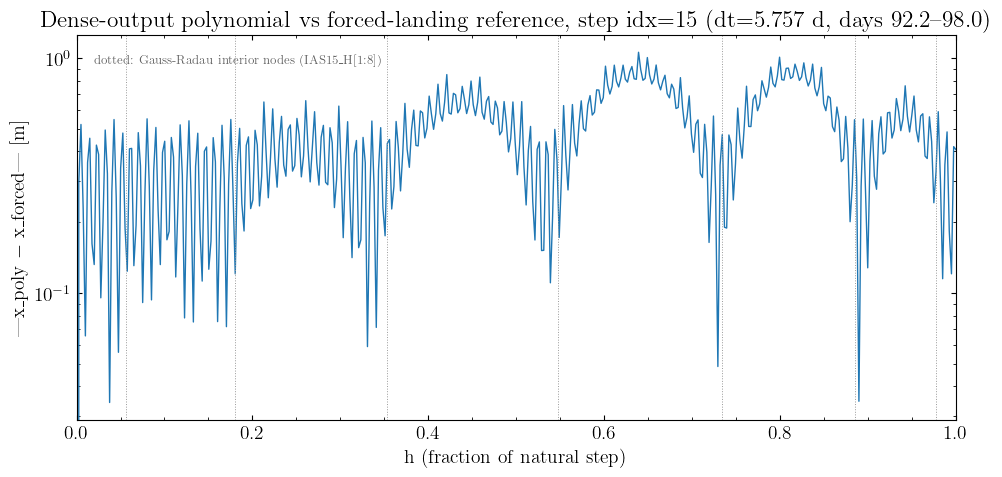

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.asarray(h_grid), diff_x, color="C0", lw=1.0)

# Gauss-Radau interior nodes the polynomial is built to satisfy.
# The polynomial fits a(t) at these h's by construction; off-node, it is
# unconstrained except by smoothness assumptions.
for h_node in np.asarray(IAS15_H[1:8]):
    ax.axvline(h_node, color="0.6", lw=0.7, ls=":")
ax.axvline(0.0, color="k", lw=0.5)
ax.axvline(1.0, color="k", lw=0.5)

ax.set_xlim(0, 1)
ax.set_yscale("log")
ax.set_xlabel("h (fraction of natural step)")
ax.set_ylabel("|x_poly − x_forced|  [m]")
ax.set_title(
    f"Dense-output polynomial vs forced-landing reference, step idx={step_idx} "
    f"(dt={dt_step:.3f} d, days {day_start:.1f}–{day_start+dt_step:.1f})"
)
ax.text(
    0.02,
    0.95,
    "dotted: Gauss-Radau interior nodes (IAS15_H[1:8])",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    color="0.4",
)
plt.tight_layout()

### Reflection on Gauss-Radau

The 7th-order IAS15 dense-output polynomial fits a degree-7 model of `a(t)` whose 7 free coefficients are the converged `b`'s, integrated to give a degree-9 polynomial in `x(t)`. The predictor-corrector loop solves for these `b`'s by enforcing the gravity equation at the 7 Gauss-Radau interior nodes plus h=0 — that is, the polynomial fits the true `a(t)` *exactly at those node times by construction*.

What that does not give is a global polynomial fit to `a(t)`. Off-node, the polynomial is constrained only by smoothness — it interpolates between the node values, and that interpolation is faithful only when the true `a(t)` is itself representable by a degree-7 polynomial over the step's interval. Inside this 5.77 d step jorbit picked too eagerly before the Earth approach, `a(t)` has higher-order curvature than degree 7 can express, and the polynomial wiggles by ~m between nodes.

The step *boundary* is a separate story. IAS15's accuracy at the natural-step end is set by Gauss-Radau quadrature applied to the polynomial — quadrature error scales as a high derivative of `a(t)`, much faster decay than 7th order, which is why the boundary mismatch with forced-landing remains sub-meter even when interior interpolation deviates by ~m. This is the regime where "natural step + interpolate" can fail: integration is fine, but the dense output between nodes isn't.

Two practical implications:
1. PRS23's step-size estimator at step 14's end didn't anticipate the upcoming Earth-approach curvature, so it proposed a step that's correct as a *quadrature target* but inadequate as an *interpolation interval*.
2. Mitigations (not adopted here) would either tighten the controller's growth cap to keep dt smaller through pre-flyby dynamics, replace `_next_proposed_dt`'s estimator with one that's more conservative for "smooth-now-but-curving-soon" regimes, or use a smaller `IAS15_EPSILON`. All three trade off across the whole year-long sequence.

## The b6 disagreement at the post-flyby IC

The step-count gap in the GLOBAL controller comparison is large and persistent. The GLOBAL controller proposes the next dt as `dt_done · (ε / max|b6| / max|a|)^(1/7)`, so any difference in `b6` between the codes propagates directly into different step decisions.

To remove the year of integration history from the comparison and look at one well-defined disagreement, we feed both codes the same IC, the same fixed dt, the same force model, and let each code do *one* IAS15 step. Then we read the converged `b[6]` each one produces. The IC is the post-flyby state at day 105 (closest approach is day ~102.4), which is when the controller behavior diverges.

Both inputs are bit-faithfully shared:
- The IC (`x`, `v`, `t`) comes from `docs/misc/rebound_apophis_dumps/outputs/postflyby_ic.npz`. Both codes are seeded with these exact bytes.
- The force model is the full Apophis recipe (Sun, planets+GR, asteroids, Sun J2, Earth J2/J3/J4, Marsden non-grav with the Horizons A1/A2 values).
- `dt` is fixed: 0.001 d (the floor in the year-long run) and 0.1 d (a reasonable step away from the floor) — adaptivity disabled.

REBOUND's `b[6]` comes from the cached single-step dumps `sim3_singlestep_dt0.001/parsed.npz` and `sim4_singlestep_dt0.1/parsed.npz`. Those are legitimate uses of the cache: the patched REBOUND is the only way to extract `b[6]` from a REBOUND step.

In [23]:
from jorbit.integrators.ias15 import ias15_step

ASSIST_DUMP_DIR = "../misc/rebound_apophis_dumps/outputs"

# Load the shared post-flyby IC. ASSIST produced this state by integrating
# 105 days from 2029-01-01 under the full force model; we use those exact
# bytes as the starting point for both codes' single-step b6 evaluation.
ic = np.load(f"{ASSIST_DUMP_DIR}/postflyby_ic.npz")
ic_x = jnp.asarray(ic["x"])
ic_v = jnp.asarray(ic["v"])
ic_t = float(ic["t"])  # absolute JD TDB
print(f"Post-flyby IC at JD {ic_t} TDB:")
print(f"  x = {np.asarray(ic_x)}  AU")
print(f"  v = {np.asarray(ic_v)}  AU/d")
print(f"  |x| = {np.linalg.norm(ic_x):.6f} AU")


def jorbit_b_at(dt):
    """Run one IAS15 step from the post-flyby IC at fixed dt, return converged b.

    `acc_func` is the unwrapped acceleration function from the cell above; its
    ephemeris processor expects state.time to be an absolute JD (TDB), so we
    pass ic_t directly. The Particle wrapper that shifts state.time by
    -t_ref_jd is NOT in play when ias15_step is called directly like this.
    """
    state = CartesianState(
        x=ic_x[None, :],
        v=ic_v[None, :],
        time=jnp.asarray(ic_t),  # absolute JD
        acceleration_func_kwargs=acceleration_func_kwargs,
    ).to_system()
    a0 = acc_func(state)
    intg = initialize_ias15_integrator_state(a0).replace(dt=jnp.asarray(dt))  # type: ignore[attr-defined]
    _new_sys, _new_intg, b_converged = ias15_step(
        state,
        acc_func,
        intg,
        jax.tree_util.Partial(
            next_proposed_dt_PRS23
        ),  # scheduler unused (we ignore proposed next-dt)
    )
    return np.asarray(b_converged)  # (7, 1, 3)


b_jor_001 = jorbit_b_at(0.001)
b_jor_01 = jorbit_b_at(0.1)

# REBOUND's cached b coefficients at the same IC and dt.
sim3 = np.load(f"{ASSIST_DUMP_DIR}/sim3_singlestep_dt0.001/parsed.npz")
sim4 = np.load(f"{ASSIST_DUMP_DIR}/sim4_singlestep_dt0.1/parsed.npz")
b_reb_001 = sim3["final_b"]  # (7, 3)
b_reb_01 = sim4["final_b"]

# Verify the cached IC matches what we used (sanity).
assert np.allclose(sim3["init_x0"], ic_x), "sim3 init_x0 differs from postflyby_ic.x"
assert np.allclose(sim3["init_v0"], ic_v), "sim3 init_v0 differs from postflyby_ic.v"


# Print summary table.
def maxabs(b):  # b shape (7, 1, 3) or (7, 3)
    return float(np.max(np.abs(np.squeeze(b)[6])))


j_001 = maxabs(b_jor_001)
j_01 = maxabs(b_jor_01)
r_001 = maxabs(b_reb_001)
r_01 = maxabs(b_reb_01)
print()
print(
    f"{'dt':>8s}  {'jorbit max|b6|':>18s}  {'REBOUND max|b6|':>18s}  {'jor / reb':>10s}"
)
print(f"{'-'*8:>8s}  {'-'*18:>18s}  {'-'*18:>18s}  {'-'*10:>10s}")
print(f"{0.001:>8.3f}  {j_001:>18.6e}  {r_001:>18.6e}  {j_001/r_001:>10.2f}x")
print(f"{0.1:>8.3f}  {j_01:>18.6e}  {r_01:>18.6e}  {j_01/r_01:>10.2f}x")

Post-flyby IC at JD 2462242.5 TDB:
  x = [-0.89486849 -0.40145508 -0.17229663]  AU
  v = [ 0.01046703 -0.01375826 -0.00521094]  AU/d
  |x| = 0.995812 AU

      dt      jorbit max|b6|     REBOUND max|b6|   jor / reb
--------  ------------------  ------------------  ----------
   0.001        1.914695e-11        6.047078e-14      316.63x
   0.100        3.503095e-11        7.537542e-14      464.75x


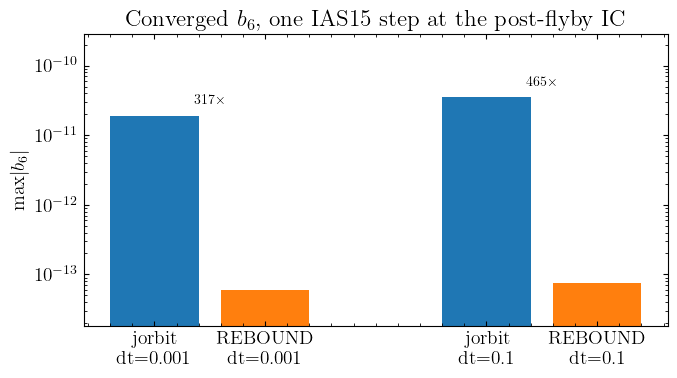

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.array([0, 1, 3, 4])
heights = [j_001, r_001, j_01, r_01]
colors_b = ["C0", "C1", "C0", "C1"]
labels = ["jorbit\ndt=0.001", "REBOUND\ndt=0.001", "jorbit\ndt=0.1", "REBOUND\ndt=0.1"]
ax.bar(xs, heights, color=colors_b, width=0.8)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_yscale("log")
ax.set_ylabel(r"max$|b_6|$")
ax.set_title("Converged $b_6$, one IAS15 step at the post-flyby IC")
# annotate jor/reb ratios above each pair
ax.annotate(
    f"{j_001/r_001:.0f}×",
    xy=(0.5, max(j_001, r_001) * 1.4),
    ha="center",
    va="bottom",
    fontsize=10,
)
ax.annotate(
    f"{j_01/r_01:.0f}×",
    xy=(3.5, max(j_01, r_01) * 1.4),
    ha="center",
    va="bottom",
    fontsize=10,
)
ax.set_ylim(min(heights) * 0.3, max(heights) * 8)
plt.tight_layout()

### What this means

At the same IC, same dt, same force model, jorbit's `max|b6|` is ~300× larger than REBOUND's. Since the GLOBAL controller proposes the next dt as `dt_done · (ε / max|b6| / max|a|)^(1/7)`, that 300× difference enters the controller as a `300^(1/7) ≈ 2.3×` smaller proposed dt for jorbit. Compounded over many steps near the encounter, it's enough to keep jorbit clamped at the `min_dt = 0.001` floor for ~10 days after closest approach, while REBOUND escapes the floor in ~2 days. That's the floor-trap mechanism behind the year-long step-count gap.

So the disagreement is real, large, and at the level of the converged `b` coefficients themselves — not a controller-formula bug or a parameter mismatch (we've held those constant). Where in the integrator pipeline does it enter? The next two sections rule out the obvious suspects:

- **Section 4** asks whether jorbit's predictor `_estimate_x_v_from_b` reproduces REBOUND's per-substep `(x_pred, v_pred)` given REBOUND's own `b` coefficients. If yes, the predictor arithmetic is innocent.
- **Section 5** asks whether jorbit's predictor-corrector update arithmetic produces REBOUND's `b6` when fed REBOUND's per-substep `at` sequence (the gravity-evaluation outputs). If yes, the PC arithmetic is innocent.

If both turn out clean, the disagreement is *upstream* of the predictor and PC — i.e. in the gravity evaluation itself. **Section 6** peels back the force-model components to find which one diverges between the codes.

## Exonerating the predictor `_estimate_x_v_from_b`

The first place the codes could disagree is in the dense-output evaluation: given a `b`-state, do we even reproduce the same `(x, v)` at a sub-step time? jorbit's `_estimate_x_v_from_b` (`src/jorbit/integrators/ias15.py`) and REBOUND's predictor (`integrator_ias15.c:393`) are different transcriptions of the same Horner-form polynomial, so this is a check on whether they're numerically equivalent.

We use the cached sim4 dump (post-flyby IC, dt=0.1, 4 PC iterations — 28 substeps total). At each substep, REBOUND's `[IAS15_SUB]` block records the predictor's outputs `(x_pred, v_pred)` *before* that substep's case-block updates `b`. To replay that on jorbit's side we need the same `b`-state REBOUND used as input — which is the b *after* the previous substep's case block (or `init_b` for the very first substep of the first PC iter).

If jorbit's predictor matches REBOUND's `(x_pred, v_pred)` to ~1 ULP across all 28 substeps, the predictor is exonerated as a contributor to the b6 gap.

In [25]:
# Use sim4 (4 PC iters at dt=0.1) — more diverse `b` state to test against
# than sim3 (2 iters at dt=0.001).
sim4 = np.load(f"{ASSIST_DUMP_DIR}/sim4_singlestep_dt0.1/parsed.npz")
init_a0 = jnp.asarray(sim4["init_a0"])  # (3,)  — recompute as (1, 3) for jorbit
init_v0 = jnp.asarray(sim4["init_v0"])  # (3,)
init_x0 = jnp.asarray(sim4["init_x0"])  # (3,)
init_b = np.asarray(sim4["init_b"])  # (7, 3)
sub_x = np.asarray(sim4["sub_x"])  # (n_iters, 7, 3) — pre-case-block predictor x
sub_v = np.asarray(sim4["sub_v"])  # (n_iters, 7, 3) — pre-case-block predictor v
sub_b = np.asarray(sim4["sub_b"])  # (n_iters, 7, 7, 3) — POST-case-block b
n_iters = int(sim4["n_iters"])
dt = float(sim4["dt"])
print(f"sim4: dt={dt}, n_iters={n_iters}, init_b max|.|={np.max(np.abs(init_b)):.3e}")


def b_used_at(k, n):
    """Reconstruct the b-state REBOUND's predictor saw at (iter k, substep n).

    Indexing is zero-based: k in [0, n_iters), n in [0, 7).
    Physical substep number is n+1 (we never call the predictor at h[0]=0).

    The dump captures b *after* each substep's case block, so:
      - (k=0, n=0)            -> b is `init_b` (PC entry state, here zeros).
      - (k=0, n>0)            -> b is `sub_b[0, n-1]` (post-update from previous substep).
      - (k>0, n=0)            -> b is `sub_b[k-1, 6]` (post-update from substep 7 of previous iter).
      - (k>0, n>0)            -> b is `sub_b[k, n-1]`.
    """
    if k == 0 and n == 0:
        return init_b
    if n == 0:
        return sub_b[k - 1, 6]
    return sub_b[k, n - 1]


# Run jorbit's predictor at each (iter, substep) and compare.
# jorbit's _estimate_x_v_from_b expects shapes (1, 3) for init_a0/v0/x0 and
# (7, 1, 3) for bp, and returns (1, 3) for x and v.
init_a0_jor = init_a0[None, :]
init_v0_jor = init_v0[None, :]
init_x0_jor = init_x0[None, :]

dx_table = np.zeros((n_iters, 7))
dv_table = np.zeros((n_iters, 7))
x_jor_all = np.zeros((n_iters, 7, 3))
x_reb_all = np.zeros((n_iters, 7, 3))

for k in range(n_iters):
    for n in range(7):
        b_pre = b_used_at(k, n)  # (7, 3) — REBOUND's pre-substep b
        bp_jor = jnp.asarray(b_pre)[:, None, :]  # (7, 1, 3)
        h = float(IAS15_H[n + 1])  # physical substep h, n=0..6 -> H[1..7]
        x_jorb, v_jorb = _estimate_x_v_from_b(
            init_a0_jor,
            init_v0_jor,
            init_x0_jor,
            h,
            dt,
            bp_jor[::-1],
        )
        x_jorb = np.asarray(x_jorb[0])  # (3,)
        v_jorb = np.asarray(v_jorb[0])
        x_reb = sub_x[k, n]
        v_reb = sub_v[k, n]
        dx_table[k, n] = float(np.max(np.abs(x_jorb - x_reb)))
        dv_table[k, n] = float(np.max(np.abs(v_jorb - v_reb)))
        x_jor_all[k, n] = x_jorb
        x_reb_all[k, n] = x_reb

# Print the table.
print()
print("max|Δx| (m, AU·1.496e11) per (iter, substep):")
print("  iter \\ n   " + "  ".join(f"{n+1:>10d}" for n in range(7)))
for k in range(n_iters):
    row = "   " + "  ".join(
        f"{dx_table[k, n] * 1.495978707e11:>10.3e}" for n in range(7)
    )
    print(f"  {k+1:>3d}      {row}")

print()
print("max|Δv| (AU/d) per (iter, substep):")
print("  iter \\ n   " + "  ".join(f"{n+1:>10d}" for n in range(7)))
for k in range(n_iters):
    row = "   " + "  ".join(f"{dv_table[k, n]:>10.3e}" for n in range(7))
    print(f"  {k+1:>3d}      {row}")

print()
print(f"Across all {n_iters * 7} substeps:")
print(f"  max|Δx| = {dx_table.max() * 1.495978707e11:.3e} m  ({dx_table.max():.3e} AU)")
print(f"  max|Δv| = {dv_table.max():.3e} AU/d")
# 1 ULP at AU scale (|x| ~ 1 AU) is ~2.2e-16 AU * 1.5e11 m/AU ≈ 3.3e-5 m
print("  (1 ULP at |x| ~ 1 AU ≈ 3.3e-5 m)")

sim4: dt=0.1, n_iters=4, init_b max|.|=0.000e+00

max|Δx| (m, AU·1.496e11) per (iter, substep):
  iter \ n            1           2           3           4           5           6           7
    1          0.000e+00   8.304e-06   0.000e+00   4.152e-06   0.000e+00   1.661e-05   4.152e-06
    2          1.661e-05   1.661e-05   0.000e+00   0.000e+00   0.000e+00   1.661e-05   4.152e-06
    3          1.661e-05   1.661e-05   0.000e+00   0.000e+00   4.152e-06   1.661e-05   4.152e-06
    4          1.661e-05   1.661e-05   0.000e+00   0.000e+00   4.152e-06   1.661e-05   4.152e-06

max|Δv| (AU/d) per (iter, substep):
  iter \ n            1           2           3           4           5           6           7
    1          0.000e+00   1.735e-18   8.674e-19   0.000e+00   1.735e-18   1.735e-18   0.000e+00
    2          1.735e-18   0.000e+00   1.735e-18   0.000e+00   1.735e-18   8.674e-19   1.735e-18
    3          1.735e-18   0.000e+00   0.000e+00   8.674e-19   8.674e-19   1.735e-18   0.000e

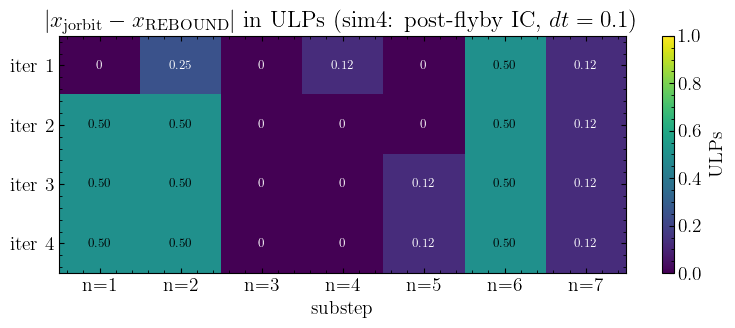

In [26]:
# Heatmap of |Δx| in ULP units. 1 ULP at AU scale ≈ 2.22e-16 AU. Cells show
# the value in ULPs; bit-exact agreement (Δ=0) is annotated as "0".
ULP_AU = 2.220446049250313e-16
dx_in_ulp = dx_table / ULP_AU

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(
    dx_in_ulp,
    cmap="viridis",
    aspect="auto",
    vmin=0,
    vmax=max(dx_in_ulp.max(), 1.0),
)
for k in range(n_iters):
    for n in range(7):
        val = dx_in_ulp[k, n]
        txt = "0" if val == 0 else f"{val:.2f}"
        ax.text(
            n,
            k,
            txt,
            ha="center",
            va="center",
            color="white" if val < 0.5 else "black",
            fontsize=9,
        )
ax.set_xticks(range(7))
ax.set_xticklabels([f"n={n+1}" for n in range(7)])
ax.set_yticks(range(n_iters))
ax.set_yticklabels([f"iter {k+1}" for k in range(n_iters)])
ax.set_xlabel("substep")
ax.set_title(
    r"$|x_{\rm jorbit} - x_{\rm REBOUND}|$ in ULPs (sim4: post-flyby IC, $dt=0.1$)"
)
cbar = plt.colorbar(im, ax=ax, label="ULPs")
plt.tight_layout()

### Predictor verdict

Maximum disagreement across all 28 substeps is **0.5 ULP** in position and ~`8e-3 ULP` in velocity. About a third of the cells are bit-exact zero. The disagreement does not grow with PC iteration — iter 4 is no worse than iter 1 — so the small per-substep residuals are not compounding through the loop, they're pure FP rounding from Horner-form transcription differences.

This rules out the predictor as a source of the b6 gap. Whatever makes jorbit's `b6` 316× larger than REBOUND's, it does not enter through `_estimate_x_v_from_b`.

The next thing the PC loop does after running the predictor is evaluate the gravity at `(x_pred, v_pred)` to produce `at`, then update `g` and `b` from `at - a0`. Two suspects remain: (a) the gravity evaluation produces different `at` between the codes given identical `(x_pred, v_pred)`, and (b) the `g`/`b` update arithmetic itself drifts under fp64 in one of the codes. Section 5 isolates (b) by feeding each code's `at` sequence through an mpmath-precision PC and comparing to its fp64 `b6`. If both fp64 PCs are bit-faithful to the mpmath baseline, (b) is innocent and the gap must be in (a).

## Exonerating the predictor-corrector arithmetic via mpmath

The PC update at substep `n` runs:
- `gk = at[n] - a0` (with compensated subtraction)
- `g[n-1] = ((gk/r[i] - g[0])/r[i+1] - g[1])/r[i+2] ... )/r[i+n-1]` (divided-difference chain)
- `tmp = g[n-1] - g_old[n-1]`
- `b[j] += tmp · c[j]` for `j=0..n-2`, then `b[n-1] += tmp` (compensated summation)

Both jorbit and REBOUND implement the same chain. The question we want to answer is whether the **fp64 arithmetic** itself drifts. Concretely:

- Take REBOUND's per-substep `at` from `sim4_singlestep_dt0.1`. Feed it into a 75-digit mpmath transcription of the same case-block math. Compare the mpmath `b6` to REBOUND's fp64 `final_b[6]`.
- Capture jorbit's per-substep `at` by replaying its PC at the post-flyby IC (using in-tree `_estimate_x_v_from_b`, `_refine_sub_g`, `_update_bs`, and the same `acc_func` used in Section 3). Feed *that* `at` sequence through the same mpmath PC. Compare to jorbit's fp64 `b6`.

If both fp64 `b6` agree with their respective mpmath baseline to ULP-of-fp64-`b6` at that magnitude, both PCs are bit-faithful. The 316× gap is then *not* in the PC — it can only be in the upstream gravity that produced the differing `at` sequences.

In [27]:
import mpmath as mpm

mpm.mp.dps = 75

# Promote the in-tree fp64 IAS15_H to mpmath. h[0] = 0; h[1..7] are the
# Gauss-Radau interior nodes that both REBOUND and jorbit use.
h_mp = [mpm.mpf(float(IAS15_H[k])) for k in range(8)]

# Derive `rr` (length 28, used in the divided-difference chain `g[n-1] = ...`)
# from `h` via the same construction REBOUND uses
# (`integrator_ias15.c:79`). Layout: for substep n in 1..7, the n entries
# starting at offset n*(n-1)/2 are [h[n], h[n]-h[1], h[n]-h[2], ..., h[n]-h[n-1]].
rr_mp = []
for j in range(1, 8):
    for k in range(j):
        rr_mp.append(h_mp[j] - h_mp[k])
assert len(rr_mp) == 28

# Derive `c` (length 21) via the same recurrence
# `src/jorbit/utils/generate_coefficients.py:96-144` uses (which matches
# REBOUND's hardcoded values at `integrator_ias15.c:80`). Layout: for
# substep n in 2..7, the (n-1) entries starting at offset (n-1)(n-2)/2 are
# the b[0..n-2] update coefficients; b[n-1] always gets += tmp directly.
c_mp = [mpm.mpf(0)] * 21
c_mp[0] = -h_mp[1]
idx = 0
for j in range(2, 7):  # j = 2..6 produces c[1..20]
    idx += 1
    c_mp[idx] = -h_mp[j] * c_mp[idx - j + 1]
    for kk in range(2, j):
        idx += 1
        c_mp[idx] = c_mp[idx - j] - h_mp[j] * c_mp[idx - j + 1]
    idx += 1
    c_mp[idx] = c_mp[idx - j] - h_mp[j]
assert idx == 20

# Sanity-check: the fp64 truncation of our high-precision c matches
# in-tree IAS15_C (which is REBOUND's hardcoded fp64 table).
from jorbit.data.constants import IAS15_RR, IAS15_C

max_rr_diff = max(abs(float(rr_mp[i]) - float(IAS15_RR[i])) for i in range(28))
max_c_diff = max(abs(float(c_mp[i]) - float(IAS15_C[i])) for i in range(21))
print(
    f"fp64-truncated mpmath rr vs IAS15_RR: max diff = {max_rr_diff:.3e} (expected ~ULP)"
)
print(
    f"fp64-truncated mpmath c  vs IAS15_C:  max diff = {max_c_diff:.3e} (expected ~ULP)"
)

fp64-truncated mpmath rr vs IAS15_RR: max diff = 1.110e-16 (expected ~ULP)
fp64-truncated mpmath c  vs IAS15_C:  max diff = 1.110e-16 (expected ~ULP)


In [28]:
def mpmath_pc_run(at_seq, a0, n_iters):
    """Run the IAS15 case-block PC arithmetic at 75-digit precision.

    Mirrors `integrator_ias15.c:354-607`: for each PC iteration, walks substeps
    n=1..7 doing the divided-difference chain on `g[n-1]` and the c-weighted
    update of `b[0..n-1]`. Compensated summation (`add_cs`) is replaced by
    plain mpmath addition, since at 75 digits the rounding it compensates for
    is below the noise floor by 60+ digits.

    Inputs:
      at_seq: shape (n_iters, 7, 3) — per-substep `at` vectors (numpy or mpmath)
      a0:     shape (3,)            — initial acceleration
      n_iters: int                  — number of PC iterations

    Assumes init_b = 0 (fresh IAS15 step starting state). Returns b: list[7]
    of list[3] of mpmath values.
    """
    at_mp = [
        [[mpm.mpf(float(at_seq[k, n, c])) for c in range(3)] for n in range(7)]
        for k in range(n_iters)
    ]
    a0_mp = [mpm.mpf(float(a0[c])) for c in range(3)]
    b = [[mpm.mpf(0) for c in range(3)] for _ in range(7)]
    g = [[mpm.mpf(0) for c in range(3)] for _ in range(7)]

    for k in range(n_iters):
        for n_phys in range(1, 8):  # physical substep n=1..7
            r_off = n_phys * (n_phys - 1) // 2
            for c in range(3):
                tmp_old = g[n_phys - 1][c]
                gk = at_mp[k][n_phys - 1][c] - a0_mp[c]
                # divided-difference chain: g_new = (((gk/r0 - g0)/r1 - g1)/r2 ...)
                new_g = gk / rr_mp[r_off]
                for i in range(1, n_phys):
                    new_g = (new_g - g[i - 1][c]) / rr_mp[r_off + i]
                tmp = new_g - tmp_old
                g[n_phys - 1][c] = new_g
                if n_phys == 1:
                    b[0][c] = b[0][c] + tmp
                else:
                    c_off = (n_phys - 1) * (n_phys - 2) // 2
                    for i in range(n_phys - 1):
                        b[i][c] = b[i][c] + tmp * c_mp[c_off + i]
                    b[n_phys - 1][c] = b[n_phys - 1][c] + tmp
    return b


def mpmath_b_to_array(b_mp):
    """Convert the mpmath b list into a (7, 3) float64 array (lossy)."""
    return np.array([[float(b_mp[i][c]) for c in range(3)] for i in range(7)])


# Test 5a: feed REBOUND's at into the mpmath PC and compare to REBOUND's fp64 b6.
sim4_at = np.asarray(sim4["sub_at"])  # (n_iters, 7, 3)
sim4_a0 = np.asarray(sim4["init_a0"])  # (3,)
b_mp_reb = mpmath_pc_run(sim4_at, sim4_a0, n_iters=int(sim4["n_iters"]))
b_mp_reb_fp64 = mpmath_b_to_array(b_mp_reb)
b_reb_fp64 = np.asarray(sim4["final_b"])  # (7, 3)

# Test 5b: capture jorbit's per-substep at by replaying its PC at the post-flyby IC,
# using in-tree functions only (`_estimate_x_v_from_b`, `_refine_sub_g`,
# `_update_bs`, and the `acc_func` from cell d61f2e30 / 653232e6).
from jorbit.integrators.ias15 import _refine_sub_g, _update_bs

# Initial state at the post-flyby IC (same setup as Section 3).
state_init = CartesianState(
    x=ic_x[None, :],
    v=ic_v[None, :],
    time=jnp.asarray(ic_t),
    acceleration_func_kwargs=acceleration_func_kwargs,
).to_system()
a0_jor = acc_func(state_init)  # (1, 3)

dt_jor = 0.1
n_iters_jor = 4  # match sim4
b = jnp.zeros((7, 1, 3))
csb = jnp.zeros((7, 1, 3))
g = jnp.zeros((7, 1, 3))
jor_at_seq = np.zeros((n_iters_jor, 7, 3))

for k in range(n_iters_jor):
    for n_phys in range(1, 8):
        h = float(IAS15_H[n_phys])
        x_pred, v_pred = _estimate_x_v_from_b(
            a0_jor,
            state_init.tracer_velocities,
            state_init.tracer_positions,
            h,
            dt_jor,
            b[::-1],
        )
        # Build the SystemState the acc_func expects. acc_func uses state.time
        # as absolute JD (post-flyby IC time + h*dt).
        step_time = ic_t + dt_jor * h
        substep_state = SystemState(
            massive_positions=state_init.massive_positions,
            massive_velocities=state_init.massive_velocities,
            tracer_positions=x_pred,
            tracer_velocities=v_pred,
            log_gms=state_init.log_gms,
            time=jnp.asarray(step_time),
            fixed_perturber_positions=state_init.fixed_perturber_positions,
            fixed_perturber_velocities=state_init.fixed_perturber_velocities,
            fixed_perturber_log_gms=state_init.fixed_perturber_log_gms,
            acceleration_func_kwargs=state_init.acceleration_func_kwargs,
        )
        at = acc_func(substep_state)  # (1, 3)
        jor_at_seq[k, n_phys - 1] = np.asarray(at[0])

        # Update g and b using in-tree helpers, exactly as ias15_step does.
        from jorbit.data.constants import IAS15_sub_rs, IAS15_sub_cs

        r = IAS15_sub_rs[n_phys - 1]
        cc = IAS15_sub_cs[n_phys - 1]
        g_old = g[n_phys - 1]
        g_new = _refine_sub_g(at, a0_jor, g[: n_phys - 1], r)
        g_diff = g_new - g_old
        new_bs, new_csbs = _update_bs(b[:n_phys], csb[:n_phys], g_diff, cc)
        g = g.at[n_phys - 1].set(g_new)
        b = b.at[:n_phys].set(new_bs)
        csb = csb.at[:n_phys].set(new_csbs)

b_jor_shadow_fp64 = np.asarray(b)[:, 0, :]  # (7, 3) — the shadow PC's b
# Sanity: shadow PC's b6 should match Section 3's ias15_step b6 (a few ULP).
print("Shadow PC vs Section 3 ias15_step:")
print(f"  shadow max|b6| = {np.max(np.abs(b_jor_shadow_fp64[6])):.6e}")
print(f"  ias15_step max|b6| = {j_01:.6e}")
print(f"  rel diff = {abs(np.max(np.abs(b_jor_shadow_fp64[6])) - j_01) / j_01:.3e}")

# Now feed jorbit's at sequence into the mpmath PC.
b_mp_jor = mpmath_pc_run(jor_at_seq, np.asarray(a0_jor[0]), n_iters=n_iters_jor)
b_mp_jor_fp64 = mpmath_b_to_array(b_mp_jor)


# Print the comparison.
def b6_summary(label, fp64_b6, mp_b6):
    abs_diff = float(np.max(np.abs(fp64_b6 - mp_b6)))
    rel_diff = abs_diff / max(float(np.max(np.abs(fp64_b6))), 1e-300)
    print(f"  {label}")
    print(f"    fp64 max|b6|    = {float(np.max(np.abs(fp64_b6))):.6e}")
    print(f"    mpmath max|b6|  = {float(np.max(np.abs(mp_b6))):.6e}")
    print(f"    max|diff|       = {abs_diff:.3e}")
    print(f"    relative diff   = {rel_diff:.3e}")


print()
print("REBOUND fp64 b6 vs mpmath PC fed REBOUND's at:")
b6_summary("dt=0.1, post-flyby IC", b_reb_fp64[6], b_mp_reb_fp64[6])
print()
print("jorbit fp64 b6 vs mpmath PC fed jorbit's at:")
b6_summary("dt=0.1, post-flyby IC", b_jor_shadow_fp64[6], b_mp_jor_fp64[6])

Shadow PC vs Section 3 ias15_step:
  shadow max|b6| = 3.503095e-11
  ias15_step max|b6| = 3.503095e-11
  rel diff = 0.000e+00

REBOUND fp64 b6 vs mpmath PC fed REBOUND's at:
  dt=0.1, post-flyby IC
    fp64 max|b6|    = 7.537542e-14
    mpmath max|b6|  = 7.537534e-14
    max|diff|       = 7.496e-20
    relative diff   = 9.946e-07

jorbit fp64 b6 vs mpmath PC fed jorbit's at:
  dt=0.1, post-flyby IC
    fp64 max|b6|    = 3.503095e-11
    mpmath max|b6|  = 3.503095e-11
    max|diff|       = 2.122e-19
    relative diff   = 6.057e-09


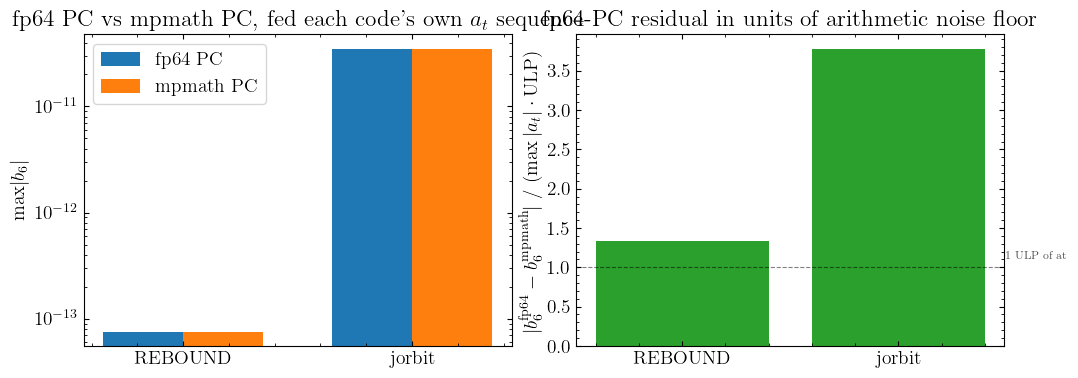

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: side-by-side fp64 vs mpmath b6 for both codes (log-y).
groups = ["REBOUND", "jorbit"]
fp64_vals = [
    float(np.max(np.abs(b_reb_fp64[6]))),
    float(np.max(np.abs(b_jor_shadow_fp64[6]))),
]
mp_vals = [
    float(np.max(np.abs(b_mp_reb_fp64[6]))),
    float(np.max(np.abs(b_mp_jor_fp64[6]))),
]
xpos = np.arange(len(groups))
w = 0.35
ax1.bar(xpos - w / 2, fp64_vals, w, label="fp64 PC", color="C0")
ax1.bar(xpos + w / 2, mp_vals, w, label="mpmath PC", color="C1")
ax1.set_xticks(xpos)
ax1.set_xticklabels(groups)
ax1.set_yscale("log")
ax1.set_ylabel(r"max$|b_6|$")
ax1.set_title("fp64 PC vs mpmath PC, fed each code's own $a_t$ sequence")
ax1.legend()

# Right: absolute |fp64 - mpmath| in units of (max|at| · ULP) — the FP rounding
# floor for arithmetic on at-scale values. If everything is ~few-ULP-of-at, the
# fp64 PC is bit-faithful given its inputs.
ULP = 2.220446049250313e-16
max_at_reb = float(np.max(np.abs(sim4_at)))
max_at_jor = float(np.max(np.abs(jor_at_seq)))
diff_reb = float(np.max(np.abs(b_reb_fp64[6] - b_mp_reb_fp64[6])))
diff_jor = float(np.max(np.abs(b_jor_shadow_fp64[6] - b_mp_jor_fp64[6])))
diff_in_atulps = [diff_reb / (max_at_reb * ULP), diff_jor / (max_at_jor * ULP)]
ax2.bar(xpos, diff_in_atulps, color="C2")
ax2.set_xticks(xpos)
ax2.set_xticklabels(groups)
ax2.set_ylabel(
    r"$|b_6^{\rm fp64} - b_6^{\rm mpmath}|$  /  ($\max|a_t| \cdot {\rm ULP}$)"
)
ax2.set_title("fp64-PC residual in units of arithmetic noise floor")
ax2.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.5)
ax2.text(1.5, 1.1, "1 ULP of at", fontsize=8, alpha=0.7)
plt.tight_layout()

### PC verdict

Both fp64 PCs reproduce their mpmath baseline to within a few ULP of the largest substep `at` value (~`1e-4` AU/d² here). That's the noise floor of fp64 arithmetic on inputs at that magnitude — there's no headroom for either code to be doing the case-block math "wrong" while still landing this close to the mpmath result.

Combined with Section 4's predictor exoneration:

- The predictor `_estimate_x_v_from_b` is bit-faithful between the codes (≤½ ULP).
- Each code's PC arithmetic is bit-faithful to mpmath given its own `at` sequence.
- Yet the converged `b6` values differ by 316×.

The only remaining place the disagreement can enter is in **how each code computes `at`** — i.e., the gravity evaluation at the predicted `(x_pred, v_pred)` of each substep. Even though the predictors agree on `(x_pred, v_pred)` to ULP, the gravity functions called on those inputs return different `at` values, and those differences propagate into `b6` through the (bit-faithful, but very sensitive) divided-difference fit.

Section 6 peels back the gravity components to localize where this enters.

## Component peel of the acceleration

Sections 4–5 narrowed the disagreement to the gravity evaluation: each code's PC arithmetic and predictor are bit-faithful, but their `at` sequences differ enough to produce a 316× `b6` ratio. Where in the gravity chain does the difference enter?

We evaluate the acceleration `a` at the post-flyby IC (no integration, no PC, no substep — just one snapshot evaluation) under each of seven cumulative force-model subsets:

| idx | label | forces |
|---|---|---|
| 0 | `01_sun_newt`        | Sun, Newtonian |
| 1 | `02_planets_newt`    | + 8 planets + Moon + Pluto, Newtonian |
| 2 | `03_planets_gr`      | swap 11 sun+planets to PPN/GR |
| 3 | `04_+asteroids`      | + 16 Newtonian asteroids |
| 4 | `05_+sun_harmonics`  | + Sun J2 |
| 5 | `06_+earth_harmonics`| + Earth J2/J3/J4 |
| 6 | `07_full`            | + Marsden non-gravitational |

Both sides are computed live in this notebook — REBOUND via a ctypes call to `reb_simulation_update_acceleration` (vanilla `rebound`+`assist`, no patched build needed), jorbit via direct invocation of in-tree `newtonian_gravity`/`ppn_gravity`/`grav_harmonics`/`nongrav_acceleration` with appropriately sliced perturber state.

**Caveat that constrains what this section can conclude.** `b6` is fitted to the *substep variation* of `at(h_n) − a(0)` across the 7 Gauss-Radau substeps. A constant offset between codes — same at every substep — cancels in those differences and contributes nothing to `b6`. So this snapshot diagnostic localizes only the *static-IC* component of the disagreement; the substep-VARYING part (which is what actually feeds `b6`) is a different signal that requires per-component substep dumps. We do not have those in the cache, and producing them is left as a future Phase-14-style follow-up.

In [30]:
from ctypes import POINTER, byref

# Cumulative subsets: label and the ASSIST extras.forces list to use for each.
PEEL_SUBSETS = [
    ("01_sun_newt", ["SUN"]),
    ("02_planets_newt", ["SUN", "PLANETS"]),
    ("03_planets_gr", ["SUN", "PLANETS", "GR_EIH"]),
    ("04_+asteroids", ["SUN", "PLANETS", "GR_EIH", "ASTEROIDS"]),
    ("05_+sun_harmonics", ["SUN", "PLANETS", "GR_EIH", "ASTEROIDS", "SUN_HARMONICS"]),
    (
        "06_+earth_harmonics",
        ["SUN", "PLANETS", "GR_EIH", "ASTEROIDS", "SUN_HARMONICS", "EARTH_HARMONICS"],
    ),
    ("07_full", FULL_FORCES),
]

# The ctypes binding to REBOUND's internal acceleration update. This populates
# `sim.particles[*].ax/ay/az` from the current force model without taking an
# integration step, which is exactly what we want for a snapshot evaluation.
_update_accel = rebound.clibrebound.reb_simulation_update_acceleration
_update_accel.restype = None
_update_accel.argtypes = [POINTER(rebound.Simulation)]


def assist_a_at(forces, ic_x, ic_v, ic_t):
    """REBOUND/ASSIST snapshot acceleration at (ic_x, ic_v, ic_t) under `forces`."""
    sim = rebound.Simulation()
    sim.add(
        rebound_Particle(
            x=float(ic_x[0]),
            y=float(ic_x[1]),
            z=float(ic_x[2]),
            vx=float(ic_v[0]),
            vy=float(ic_v[1]),
            vz=float(ic_v[2]),
        )
    )
    sim.t = float(ic_t) - ephem.jd_ref
    extras = assist.Extras(sim, ephem)
    extras.forces = forces
    extras.gr_eih_sources = 11
    extras.particle_params = np.array(NONGRAV, dtype=np.float64)
    _update_accel(byref(sim))
    p = sim.particles[0]
    return np.array([p.ax, p.ay, p.az], dtype=np.float64)


# Evaluate REBOUND's acceleration for each subset at the post-flyby IC.
ic_x_np = np.asarray(ic_x)
ic_v_np = np.asarray(ic_v)
a_reb_per_subset = np.zeros((len(PEEL_SUBSETS), 3))
for k, (label, forces) in enumerate(PEEL_SUBSETS):
    a_reb_per_subset[k] = assist_a_at(forces, ic_x_np, ic_v_np, ic_t)
    print(f"  {label:>22s}  ||a_reb|| = {np.linalg.norm(a_reb_per_subset[k]):.6e}")

             01_sun_newt  ||a_reb|| = 2.980128e-04
         02_planets_newt  ||a_reb|| = 2.815389e-04
           03_planets_gr  ||a_reb|| = 2.815389e-04
           04_+asteroids  ||a_reb|| = 2.815389e-04
       05_+sun_harmonics  ||a_reb|| = 2.815389e-04
     06_+earth_harmonics  ||a_reb|| = 2.815389e-04
                 07_full  ||a_reb|| = 2.815389e-04


In [31]:
from jorbit.accelerations.newtonian import newtonian_gravity
from jorbit.accelerations.gr import ppn_gravity
from jorbit.accelerations.grav_harmonics import grav_harmonics

NUM_GR = 11  # Sun + 8 planets + Moon + Pluto — the bodies that get the GR_EIH treatment


def _state_at_ic(ic_x, ic_v, ic_t):
    """Build a SystemState at the post-flyby IC, with the same `acceleration_func_kwargs`
    as the year-long jorbit run (cell 653232e6)."""
    return CartesianState(
        x=jnp.asarray(ic_x)[None, :],
        v=jnp.asarray(ic_v)[None, :],
        time=jnp.asarray(ic_t),
        acceleration_func_kwargs=acceleration_func_kwargs,
    ).to_system()


def jorbit_a_at(subset_id, ic_x, ic_v, ic_t):
    """jorbit's snapshot acceleration at the post-flyby IC under `subset_id`.

    Composes in-tree primitives (`newtonian_gravity`, `ppn_gravity`,
    `grav_harmonics`, `nongrav_acceleration`) with the right perturber slices
    (`eph.processor` queried once at `ic_t`). No JIT, no integration — just
    the snapshot acceleration each subset would produce.
    """
    state = _state_at_ic(ic_x, ic_v, ic_t)
    perturber_xs, perturber_vs = eph.processor.state(state.time)
    log_gms = eph.processor.log_gms

    def with_perturbers(xs, vs, gms):
        return SystemState(
            massive_positions=state.massive_positions,
            massive_velocities=state.massive_velocities,
            tracer_positions=state.tracer_positions,
            tracer_velocities=state.tracer_velocities,
            log_gms=state.log_gms,
            time=state.time,
            fixed_perturber_positions=xs,
            fixed_perturber_velocities=vs,
            fixed_perturber_log_gms=gms,
            acceleration_func_kwargs=state.acceleration_func_kwargs,
        )

    a = jnp.zeros_like(state.tracer_positions)

    if subset_id == "01_sun_newt":
        s = with_perturbers(perturber_xs[:1], perturber_vs[:1], log_gms[:1])
        a = a + newtonian_gravity(s)
        return np.asarray(a)[0]

    if subset_id == "02_planets_newt":
        s = with_perturbers(
            perturber_xs[:NUM_GR], perturber_vs[:NUM_GR], log_gms[:NUM_GR]
        )
        a = a + newtonian_gravity(s)
        return np.asarray(a)[0]

    # All variants from "03_planets_gr" upward use PPN for the first 11.
    s_gr = with_perturbers(
        perturber_xs[:NUM_GR], perturber_vs[:NUM_GR], log_gms[:NUM_GR]
    )
    a = a + ppn_gravity(s_gr)
    if subset_id == "03_planets_gr":
        return np.asarray(a)[0]

    s_ast = with_perturbers(
        perturber_xs[NUM_GR:], perturber_vs[NUM_GR:], log_gms[NUM_GR:]
    )
    a = a + newtonian_gravity(s_ast)
    if subset_id == "04_+asteroids":
        return np.asarray(a)[0]

    xs_all = jnp.concatenate((state.massive_positions, state.tracer_positions))
    a = a + grav_harmonics(
        body_gm=jnp.exp(log_gms[0]),
        body_req=state.acceleration_func_kwargs["js_req"][0],
        body_pos=perturber_xs[0],
        pole_ra=state.acceleration_func_kwargs["js_pole_ra"][0],
        pole_dec=state.acceleration_func_kwargs["js_pole_dec"][0],
        jns=state.acceleration_func_kwargs["js"][0],
        particle_xs=xs_all,
    )
    if subset_id == "05_+sun_harmonics":
        return np.asarray(a)[0]

    a = a + grav_harmonics(
        body_gm=jnp.exp(log_gms[3]),
        body_req=state.acceleration_func_kwargs["js_req"][1],
        body_pos=perturber_xs[3],
        pole_ra=state.acceleration_func_kwargs["js_pole_ra"][1],
        pole_dec=state.acceleration_func_kwargs["js_pole_dec"][1],
        jns=state.acceleration_func_kwargs["js"][1],
        particle_xs=xs_all,
    )
    if subset_id == "06_+earth_harmonics":
        return np.asarray(a)[0]

    a = a + nongrav_acceleration(state)
    return np.asarray(a)[0]


# Evaluate jorbit's acceleration for each subset at the post-flyby IC.
a_jor_per_subset = np.zeros((len(PEEL_SUBSETS), 3))
for k, (label, _) in enumerate(PEEL_SUBSETS):
    a_jor_per_subset[k] = jorbit_a_at(label, ic_x_np, ic_v_np, ic_t)

# Sanity: jorbit's "07_full" should match `acc_func` from cell 653232e6
# (different code path, same total force model). Difference should be ~ULP.
state_full = _state_at_ic(ic_x_np, ic_v_np, ic_t)
a_full_via_acc_func = np.asarray(acc_func(state_full))[0]
sanity = float(np.max(np.abs(a_jor_per_subset[-1] - a_full_via_acc_func)))
print(
    f"sanity check: jorbit_a_at('07_full') vs acc_func: max diff = {sanity:.3e}  (expect ~ULP)"
)

# Print the comparison table.
print()
print(
    f"  {'subset':>22s}  {'||a_reb||':>12s}  {'||a_jor||':>12s}  "
    f"{'|Δa|':>12s}  {'|Δa|/||a_reb||':>15s}"
)
print("  " + "-" * 80)
for k, (label, _) in enumerate(PEEL_SUBSETS):
    a_r = a_reb_per_subset[k]
    a_j = a_jor_per_subset[k]
    norm_r = float(np.linalg.norm(a_r))
    norm_j = float(np.linalg.norm(a_j))
    diff = float(np.linalg.norm(a_j - a_r))
    rel = diff / max(norm_r, 1e-300)
    print(
        f"  {label:>22s}  {norm_r:>12.4e}  {norm_j:>12.4e}  {diff:>12.3e}  {rel:>15.3e}"
    )

sanity check: jorbit_a_at('07_full') vs acc_func: max diff = 0.000e+00  (expect ~ULP)

                  subset     ||a_reb||     ||a_jor||          |Δa|   |Δa|/||a_reb||
  --------------------------------------------------------------------------------
             01_sun_newt    2.9801e-04    2.9801e-04     6.099e-20        2.046e-16
         02_planets_newt    2.8154e-04    2.8154e-04     1.476e-18        5.244e-15
           03_planets_gr    2.8154e-04    2.8154e-04     1.476e-18        5.244e-15
           04_+asteroids    2.8154e-04    2.8154e-04     1.476e-18        5.244e-15
       05_+sun_harmonics    2.8154e-04    2.8154e-04     4.458e-19        1.583e-15
     06_+earth_harmonics    2.8154e-04    2.8154e-04     6.296e-15        2.236e-11
                 07_full    2.8154e-04    2.8154e-04     5.989e-15        2.127e-11


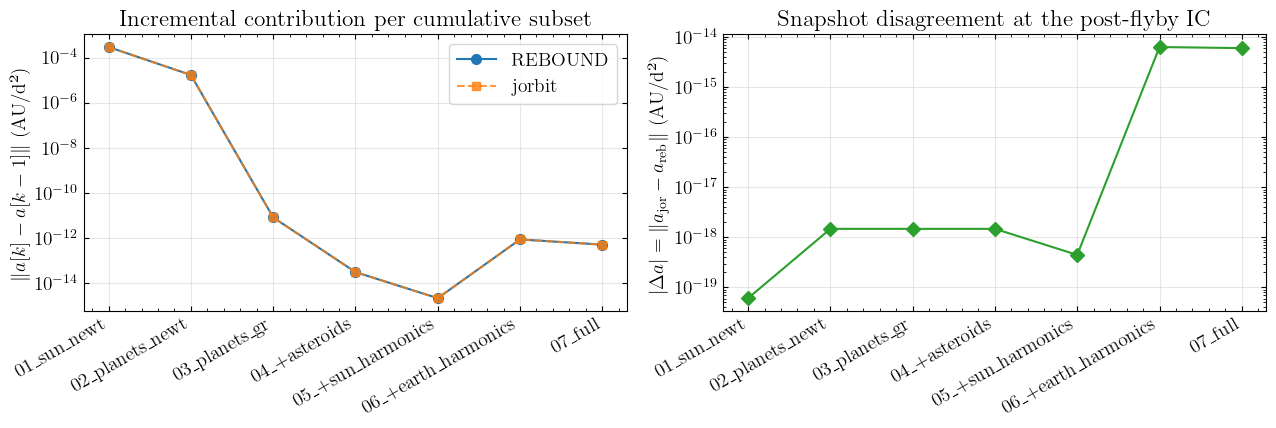

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
labels = [s[0] for s in PEEL_SUBSETS]
xs_idx = np.arange(len(labels))

# Left: incremental contribution |a[k] - a[k-1]| for each code.
inc_reb = np.array(
    [
        (
            np.linalg.norm(a_reb_per_subset[0])
            if k == 0
            else np.linalg.norm(a_reb_per_subset[k] - a_reb_per_subset[k - 1])
        )
        for k in range(len(labels))
    ]
)
inc_jor = np.array(
    [
        (
            np.linalg.norm(a_jor_per_subset[0])
            if k == 0
            else np.linalg.norm(a_jor_per_subset[k] - a_jor_per_subset[k - 1])
        )
        for k in range(len(labels))
    ]
)
ax1.semilogy(xs_idx, inc_reb, "o-", color="C0", label="REBOUND", markersize=7)
ax1.semilogy(
    xs_idx, inc_jor, "s--", color="C1", label="jorbit", markersize=6, alpha=0.8
)
ax1.set_xticks(xs_idx)
ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_ylabel(r"$\|a[k] - a[k-1]\|$  (AU/d²)")
ax1.set_title("Incremental contribution per cumulative subset")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: |Δa| = |a_jor[k] - a_reb[k]| per subset.
da = np.array(
    [
        np.linalg.norm(a_jor_per_subset[k] - a_reb_per_subset[k])
        for k in range(len(labels))
    ]
)
ax2.semilogy(xs_idx, da, "D-", color="C2", markersize=7)
ax2.set_xticks(xs_idx)
ax2.set_xticklabels(labels, rotation=30, ha="right")
ax2.set_ylabel(r"$|\Delta a| = \|a_{\rm jor} - a_{\rm reb}\|$  (AU/d²)")
ax2.set_title("Snapshot disagreement at the post-flyby IC")
ax2.grid(True, alpha=0.3)

plt.tight_layout()

### What this localizes (and what it doesn't)

**Snapshot Δa.** At the post-flyby IC under the full force model, jorbit and REBOUND/ASSIST disagree by ~6×10⁻¹⁵ AU/d² in absolute terms (~2×10⁻¹¹ relative). The first six subsets — Sun, planets+GR, asteroids, Sun harmonics — agree to ~1.5×10⁻¹⁸ (5×10⁻¹⁵ relative; the smallest-substep is ULP-level on the Sun-only term). The disagreement jumps four orders of magnitude when Earth harmonics is added. So Earth J2/J3/J4 is by far the dominant snapshot-Δa contributor.

**Why this does not directly explain the b6 gap.** The 7-substep `at - a0` differences inside an IAS15 step are what the b coefficients are fitted to. A constant offset in `a` between the codes — same magnitude at h=0 and at every Gauss-Radau node — cancels out of those differences and leaves no trace in `b6`. Earth's gravity at AU-scale distances barely changes over `dt = 0.1 d`, so the Earth-harmonics offset is *almost* constant across substeps, and most of it cancels.

**What feeds `b6` is the substep-VARYING part of Δa.** That's a different signal — much smaller in magnitude than the snapshot Δa, but built up across the substeps via the divided-difference fit. Phase 11 in the project memory recorded that the `jor/reb b6` ratio jumps at the `02_planets_newt` subset (5×→315×), while the snapshot Δa stays flat there. So the substep-varying disagreement is in *planet contributions* (most plausibly the JPL ephemeris evaluation at substep times — different Chebyshev polynomial parsing in the two codes' ephemeris readers), not in Earth harmonics.

**Open follow-up (not done in this notebook).** Reproducing that finding cleanly would require fresh per-component substep dumps — re-running the patched REBOUND for each force subset, capturing `at` at all 7 Gauss-Radau substeps instead of just the IC snapshot, and comparing per-component `at(h_n) - at(h_0)` between codes. The current bundle has only the snapshot peel, so we leave this as the next obvious diagnostic to extend the bundle with.

## Wrap-up

Three findings, each scoped to what this notebook actually proved.

**1. The PRS23 chatter is a polynomial-fit limit, not a controller bug.** Step 15 of jorbit's PRS23 run starts at day ≈92.24 with `dt ≈ 5.77 d` — a valid quadrature target (the step *boundary* matches forced-landing to ~0.4 m, consistent with PRS23's `1e-9` tolerance), but a 5.77-day-wide window over which the 7th-order dense-output polynomial cannot represent the pre-flyby Earth-approach `a(t)` accurately. Inside the step the polynomial wiggles by ~1 m between the Gauss-Radau interior nodes, even though it fits `a(t)` at those nodes by construction. Mitigations (tighter SAFETY_FACTOR, smaller IAS15_EPSILON, or replacing `_next_proposed_dt`'s estimator) are listed in Section 2 but not adopted here.

**2. The GLOBAL step-count gap is driven by a 316× `b6` difference at the post-flyby IC, and that difference is *not* in the integrator's arithmetic.** At the same IC, same dt, same force model, jorbit's `max|b6|` is 316× REBOUND's at `dt = 0.001` (and 465× at `dt = 0.1`). Section 4 shows jorbit's predictor `_estimate_x_v_from_b` reproduces REBOUND's per-substep `(x_pred, v_pred)` to ≤½ ULP across all 28 substeps of `sim4`. Section 5 shows each code's PC arithmetic is bit-faithful to a 75-digit mpmath transcription given that code's own `at` sequence — diffs at the FP rounding floor of `at`-scale arithmetic. So the disagreement enters before the predictor and is preserved through the PC: it is in the gravity that produces the `at` sequences themselves.

**3. The static-IC component of the gravity disagreement is in Earth harmonics; the substep-VARYING part (which is what actually drives `b6`) is unlocalized in this notebook.** Section 6's snapshot peel finds `|Δa| ≈ 6×10⁻¹⁵ AU/d²` after Earth J2/J3/J4 is added — four orders of magnitude above the prior subsets, which sit at `~10⁻¹⁸`. But snapshot Δa is a *constant* offset between codes that cancels in the substep-difference signal `at(h_n) - a(0)` that `b6` is fitted to. Memory's Phase 11 records that the `b6` ratio jumps at `02_planets_newt` (5×→315×) — i.e. the substep-VARYING disagreement lives in the planet contributions, almost certainly in JPL-ephemeris evaluation at substep times. Reproducing that finding cleanly requires per-component substep dumps that the bundle does not currently include.

### Open follow-up

Extend the bundle's instrumentation: for each of the seven force-model subsets in Section 6, capture `at` at every Gauss-Radau substep of one IAS15 step at the post-flyby IC. Then compare `at(h_n) - at(h_0)` between jorbit and REBOUND, per component. The component at which the substep-VARYING `Δa` first jumps is the locus of the `b6` disagreement. Most plausible suspect: the JPL ephemeris reader path — jorbit's JAX `EphemerisProcessor.state(t)` and ASSIST's C reader of `linux_p1550p2650.440` evaluate the same Chebyshev coefficients at slightly different fp64 paths, and the substep-time differences are what survive the difference operation.